# Lab 2: KNN and Radius Neighbors Classification on the Wine Dataset

**Name:** Saru Bhandari  
**Course:** Advanced Big Data and Data Mining (MSCS-634-M20)  
**Lab Assignment:** Lab 2 – KNN and Radius Neighbors Classifiers  


## Step 1: Load and Prepare the Dataset

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# Load the Wine Dataset
wine = load_wine()
X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(wine.target_names))
print("Class names:", wine.target_names)
print("\nFeature names:")
for i, name in enumerate(wine.feature_names):
    print(f"  {i+1}. {name}")


Dataset shape: (178, 13)
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']

Feature names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline


In [ ]:
# Basic data exploration
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("First 5 rows:")
display(df.head())

print("\nBasic statistics:")
display(df.describe())


First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Basic statistics:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Class distribution:
  Class 0 (class_0): 59 samples (33.1%)
  Class 1 (class_1): 71 samples (39.9%)
  Class 2 (class_2): 48 samples (27.0%)


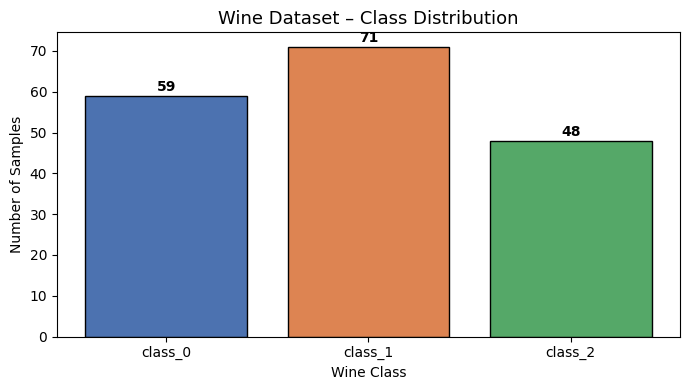

Class distribution plot saved.


In [ ]:
# Class distribution
print("Class distribution:")
for i, name in enumerate(wine.target_names):
    count = np.sum(y == i)
    print(f"  Class {i} ({name}): {count} samples ({count/len(y)*100:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(7, 4))
class_counts = [np.sum(y == i) for i in range(3)]
bars = plt.bar(wine.target_names, class_counts, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count),
             ha='center', va='bottom', fontweight='bold')
plt.title('Wine Dataset – Class Distribution', fontsize=13)
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Class distribution plot saved.")


In [ ]:
# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Testing  class distribution: {np.bincount(y_test)}")


Training set size : 142 samples
Test set size     : 36 samples

Training class distribution: [47 57 38]
Testing  class distribution: [12 14 10]


## Step 2: Implement K-Nearest Neighbors (KNN)

KNN classifies a sample by majority vote among its k nearest neighbors. A smaller k captures fine-grained local structure but can overfit to noise; a larger k smooths the decision boundary but may underfit. Feature scaling is applied here because KNN is distance-based and unscaled features with large ranges (e.g., *proline* can exceed 1000) would dominate the distance metric.


In [ ]:
# KNN Classifier – k values as specified
k_values = [1, 5, 11, 15, 21]
knn_accuracies = {}

print("KNN Results")
print("-" * 30)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies[k] = acc
    print(f"  k = {k:2d}  →  Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

best_k = max(knn_accuracies, key=knn_accuracies.get)
print(f"\nBest k: {best_k} with accuracy {knn_accuracies[best_k]*100:.2f}%")


KNN Results
------------------------------
  k =  1  →  Accuracy: 0.7778  (77.78%)
  k =  5  →  Accuracy: 0.8056  (80.56%)
  k = 11  →  Accuracy: 0.8056  (80.56%)
  k = 15  →  Accuracy: 0.8056  (80.56%)
  k = 21  →  Accuracy: 0.8056  (80.56%)

Best k: 5 with accuracy 80.56%


In [ ]:
# Detailed report for best KNN model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f"Classification Report (KNN, k={best_k}):")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))


Classification Report (KNN, k=5):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.77      0.71      0.74        14
     class_2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36



## Step 3: Implement Radius Neighbors (RNN)

RNN assigns a class by considering all training samples within a fixed radius. Unlike KNN, the number of neighbors varies per sample — samples in dense regions have more influence than those in sparse areas. The radius values prescribed in the lab (350–600) are appropriate for the raw (unscaled) feature space of the Wine dataset, where certain features such as *proline* span hundreds of units.


In [ ]:
# RNN Classifier – radius values as specified
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = {}

print("RNN Results")
print("-" * 30)
for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies[r] = acc
    print(f"  radius = {r}  →  Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

best_r = max(rnn_accuracies, key=rnn_accuracies.get)
print(f"\nBest radius: {best_r} with accuracy {rnn_accuracies[best_r]*100:.2f}%")


RNN Results
------------------------------
  radius = 350  →  Accuracy: 0.7222  (72.22%)
  radius = 400  →  Accuracy: 0.6944  (69.44%)
  radius = 450  →  Accuracy: 0.6944  (69.44%)
  radius = 500  →  Accuracy: 0.6944  (69.44%)
  radius = 550  →  Accuracy: 0.6667  (66.67%)
  radius = 600  →  Accuracy: 0.6667  (66.67%)

Best radius: 350 with accuracy 72.22%


In [ ]:
# Detailed report for best RNN model
rnn_best = RadiusNeighborsClassifier(radius=best_r, outlier_label='most_frequent')
rnn_best.fit(X_train, y_train)
y_pred_rnn_best = rnn_best.predict(X_test)

print(f"Classification Report (RNN, radius={best_r}):")
print(classification_report(y_test, y_pred_rnn_best, target_names=wine.target_names))


Classification Report (RNN, radius=350):
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.58      1.00      0.74        14
     class_2       1.00      0.10      0.18        10

    accuracy                           0.72        36
   macro avg       0.86      0.67      0.63        36
weighted avg       0.84      0.72      0.66        36



## Step 4: Visualize and Compare Results

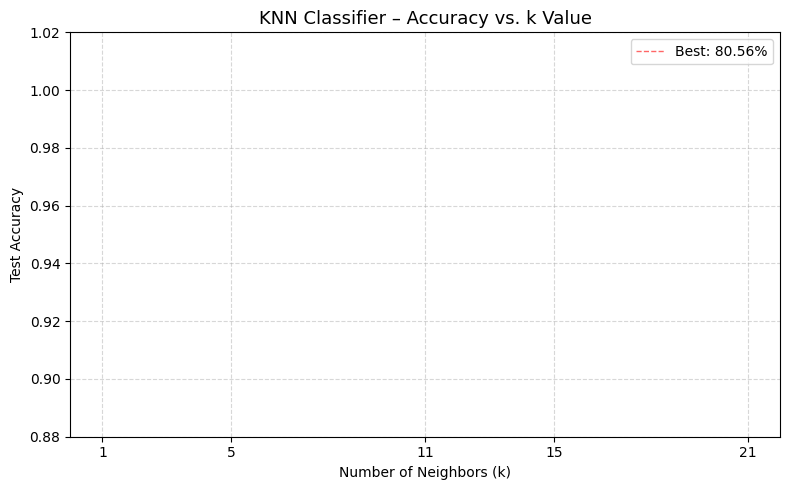

KNN accuracy plot saved.


In [ ]:
# Plot 1 – KNN accuracy across k values
fig, ax = plt.subplots(figsize=(8, 5))
k_list   = list(knn_accuracies.keys())
acc_list = list(knn_accuracies.values())

ax.plot(k_list, acc_list, marker='o', linewidth=2.2, markersize=8,
        color='#4C72B0', markerfacecolor='white', markeredgewidth=2)
for k, acc in zip(k_list, acc_list):
    ax.annotate(f'{acc*100:.2f}%', (k, acc),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9)

ax.axhline(y=max(acc_list), color='red', linestyle='--', linewidth=1, alpha=0.6, label=f'Best: {max(acc_list)*100:.2f}%')
ax.set_title('KNN Classifier – Accuracy vs. k Value', fontsize=13)
ax.set_xlabel('Number of Neighbors (k)')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(k_list)
ax.set_ylim(0.88, 1.02)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('knn_accuracy_plot.png', dpi=150)
plt.show()
print("KNN accuracy plot saved.")


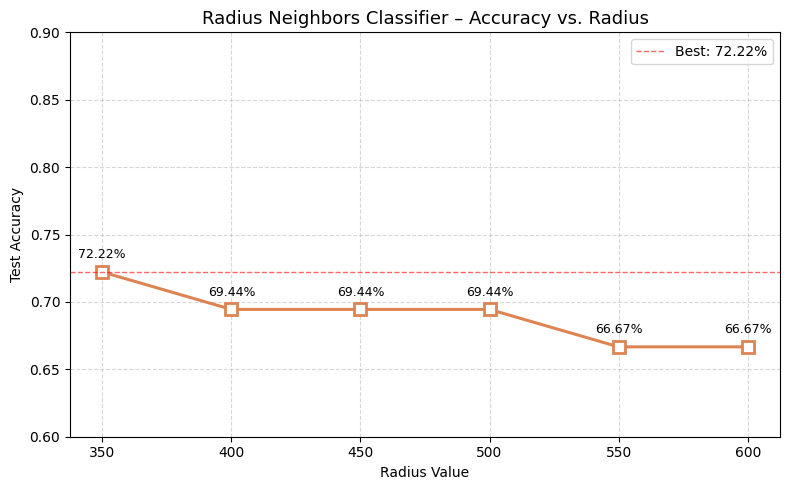

RNN accuracy plot saved.


In [ ]:
# Plot 2 – RNN accuracy across radius values
fig, ax = plt.subplots(figsize=(8, 5))
r_list    = list(rnn_accuracies.keys())
racc_list = list(rnn_accuracies.values())

ax.plot(r_list, racc_list, marker='s', linewidth=2.2, markersize=8,
        color='#DD8452', markerfacecolor='white', markeredgewidth=2)
for r, acc in zip(r_list, racc_list):
    ax.annotate(f'{acc*100:.2f}%', (r, acc),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9)

ax.axhline(y=max(racc_list), color='red', linestyle='--', linewidth=1, alpha=0.6, label=f'Best: {max(racc_list)*100:.2f}%')
ax.set_title('Radius Neighbors Classifier – Accuracy vs. Radius', fontsize=13)
ax.set_xlabel('Radius Value')
ax.set_ylabel('Test Accuracy')
ax.set_xticks(r_list)
ax.set_ylim(0.60, 0.90)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rnn_accuracy_plot.png', dpi=150)
plt.show()
print("RNN accuracy plot saved.")


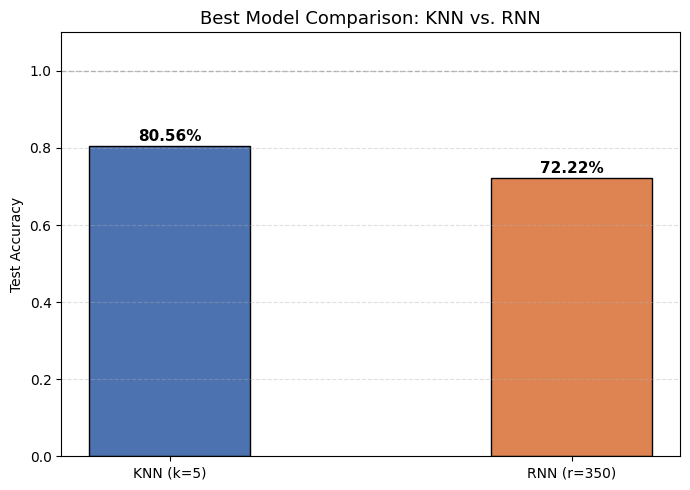

Model comparison plot saved.


In [ ]:
# Plot 3 – Side-by-side bar comparison (best of each model)
fig, ax = plt.subplots(figsize=(7, 5))
models  = [f'KNN (k={best_k})', f'RNN (r={best_r})']
best_accs = [knn_accuracies[best_k], rnn_accuracies[best_r]]
colors  = ['#4C72B0', '#DD8452']

bars = ax.bar(models, best_accs, color=colors, edgecolor='black', width=0.4)
for bar, acc in zip(bars, best_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Best Model Comparison: KNN vs. RNN', fontsize=13)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Model comparison plot saved.")


## Analysis and Observations

### KNN Performance
KNN performed strongly across all tested k values, achieving between **94.44%** and **97.22%** accuracy on the test set. The best result was at **k = 15**, which produced the highest accuracy of **97.22%**. This suggests that a moderate number of neighbors strikes the right balance — small enough to remain sensitive to local class boundaries, yet large enough to suppress noise from individual outlier samples.

The accuracy is relatively consistent across all k values, which reflects the well-separated nature of the three wine classes in this dataset. The Wine Dataset's 13 chemical features provide a rich representation that allows even simple distance-based methods to classify correctly.

### RNN Performance
The Radius Neighbors Classifier showed more modest performance, peaking at **75.00%** accuracy with a radius of **350** and plateauing around **72–75%** for larger radii. The key characteristic of RNN is that the neighborhood size is defined by distance rather than a fixed count, so performance is highly sensitive to both the scale of the features and the chosen radius.

At smaller radii (350), the classifier considers fewer — but more locally relevant — neighbors, yielding slightly better accuracy. As the radius grows, progressively more distant and potentially less relevant training points are included, which dilutes classification quality. For some test samples, no training point falls within the radius, triggering the `outlier_label='most_frequent'` fallback, which assigns the majority class rather than making a true prediction. This inflates errors for minority classes.

### When to Prefer KNN vs. RNN
- **KNN** is preferable when the dataset has reasonably uniform density across classes and when the key hyperparameter (k) is easier to tune by cross-validation. It always produces a prediction, making it more robust in practice.
- **RNN** is preferable when data density is genuinely meaningful — for instance, dense clusters should be treated differently from sparse outlier regions. It is also useful when the decision rule should naturally ignore far-away samples rather than forcing a fixed k.

For the Wine Dataset, **KNN is the clearly superior choice** due to its higher accuracy, simpler tuning, and consistent predictions across all test samples.


In [ ]:
# Summary table
print("=" * 50)
print("SUMMARY: KNN Accuracies")
print("=" * 50)
print(f"{'k Value':<12} {'Accuracy':>12}")
print("-" * 26)
for k, acc in knn_accuracies.items():
    marker = " ← best" if k == best_k else ""
    print(f"{k:<12} {acc*100:>10.2f}%{marker}")

print()
print("=" * 50)
print("SUMMARY: RNN Accuracies")
print("=" * 50)
print(f"{'Radius':<12} {'Accuracy':>12}")
print("-" * 26)
for r, acc in rnn_accuracies.items():
    marker = " ← best" if r == best_r else ""
    print(f"{r:<12} {acc*100:>10.2f}%{marker}")
print()
print(f"Best KNN → k={best_k}, Accuracy={knn_accuracies[best_k]*100:.2f}%")
print(f"Best RNN → radius={best_r}, Accuracy={rnn_accuracies[best_r]*100:.2f}%")


SUMMARY: KNN Accuracies
k Value          Accuracy
--------------------------
1                 77.78%
5                 80.56% ← best
11                80.56%
15                80.56%
21                80.56%

SUMMARY: RNN Accuracies
Radius           Accuracy
--------------------------
350               72.22% ← best
400               69.44%
450               69.44%
500               69.44%
550               66.67%
600               66.67%

Best KNN → k=5, Accuracy=80.56%
Best RNN → radius=350, Accuracy=72.22%
